# **Ejercicio 2 TP final**

### 1) Cree un dataframe de Pandas que contenga los datos del archivo titanic_processed.csv suministrado.

In [1]:
# importamos librerias que vamos a utilizar en este ejercicio

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Librerias para los arboles de decisión

import graphviz
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from graphviz import Source




In [3]:
# 1- Cargamos el Data Set solicitado

datos_titanic = pd.read_csv ("titanic_processed.csv", encoding = "ISO-8859-1")

# Escalamos los features "Age" y "fare" para una mejor convergencia
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # Escalador incializado

datos_titanic[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked_C", "Embarked_Q", "Embarked_S"]] = scaler.fit_transform(datos_titanic[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked_C", "Embarked_Q", "Embarked_S"]])


# Visualizamos los primeros 20 registros

datos_titanic.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,0.908600,0.756138,-0.527669,-0.552714,-0.506787,-0.504172,-0.472618,-0.202326,0.534040
1,1,0.908600,-1.322511,-0.251478,-0.552714,-0.506787,-0.503620,-0.472618,-0.202326,0.534040
2,0,0.908600,0.756138,-0.182430,-0.552714,-0.506787,-0.504172,-0.472618,-0.202326,0.534040
3,0,-0.287191,0.756138,0.162808,1.597735,-0.506787,0.735948,-0.472618,-0.202326,0.534040
4,0,0.908600,0.756138,2.441380,-0.552714,-0.506787,-0.506928,-0.472618,4.942527,-1.872519
5,0,0.908600,0.756138,0.059236,-0.552714,-0.506787,-0.501257,-0.472618,-0.202326,0.534040
6,0,0.908600,0.756138,0.300903,0.522511,0.664747,-0.381223,-0.472618,-0.202326,0.534040
7,1,-1.482983,0.756138,-0.872907,-0.552714,1.836282,1.442608,2.115874,-0.202326,-1.872519
8,1,-0.287191,-1.322511,0.300903,-0.552714,-0.506787,-0.454945,-0.472618,-0.202326,0.534040
9,0,0.908600,0.756138,-0.527669,-0.552714,-0.506787,-0.504172,-0.472618,-0.202326,0.534040


In [53]:
# exploramos algunas estadisticas generales



# Calculo de estadísticas generales de cada variable numérica 
print(datos_titanic.describe())
print("")


# Observamos datos faltantes 

print("Datos faltantes: por columnas",list(datos_titanic.isnull().sum()))


         Survived        Pclass           Sex           Age         SibSp  \
count  712.000000  7.120000e+02  7.120000e+02  7.120000e+02  7.120000e+02   
mean     0.404494 -1.397135e-16 -1.072800e-16  2.943962e-16  9.979533e-18   
std      0.491139  1.000703e+00  1.000703e+00  1.000703e+00  1.000703e+00   
min      0.000000 -1.482983e+00 -1.322511e+00 -2.017717e+00 -5.527137e-01   
25%      0.000000 -1.482983e+00 -1.322511e+00 -6.657639e-01 -5.527137e-01   
50%      0.000000 -2.871914e-01  7.561375e-01 -1.133826e-01 -5.527137e-01   
75%      1.000000  9.085997e-01  7.561375e-01  5.770939e-01  5.225108e-01   
max      1.000000  9.085997e-01  7.561375e-01  3.477095e+00  4.823409e+00   

              Parch          Fare    Embarked_C    Embarked_Q    Embarked_S  
count  7.120000e+02  7.120000e+02  7.120000e+02  7.120000e+02  7.120000e+02  
mean   1.122697e-17 -6.486696e-17 -4.989766e-18  1.247442e-17  1.272390e-16  
std    1.000703e+00  1.000703e+00  1.000703e+00  1.000703e+00  1.000703e

### 2)  Utilice el comando *train_test_split* para separar los datos en conjuntos de entrenamiento y prueba.
 La fracción de datos de prueba debe estar entre 20% y 30%.

In [60]:
# 2- separamos los conjuntos de datos en entrenamiento y prueba con el comando train_test_split

X = datos_titanic[["Pclass","Sex", "Age","SibSp", "Parch", "Fare", "Embarked_C", "Embarked_Q", "Embarked_S"]]
y = datos_titanic["Survived"]

# Divimos las variables

X_entrenamiento, X_test, y_entrenamiento, y_test = train_test_split(X, y, test_size = 0.28, random_state=42, stratify=y) # observamos que los datos de prueba(test_size) son del 20%

# vemos como quedo divido nuetro df y algunos procentajes 

print("Datos de entrenamiento:",len(X_entrenamiento))
print("Datos de prueba:",len(X_test))
print("Porcentaje de datos de entrenamiento: ", round(len(X_entrenamiento)*100/(len(X_entrenamiento)+len(X_test)),2))
print("Porcentaje de datos de prueba: ", round(len(X_test)*100/(len(X_entrenamiento)+len(X_test)),2))



Datos de entrenamiento: 512
Datos de prueba: 200
Porcentaje de datos de entrenamiento:  71.91
Porcentaje de datos de prueba:  28.09


### 3) Determine un modelo de clasificación de regresión logística utilizando los datos de entrenamiento. 
Este modelo debe estimar la **Supervivencia** del pasajero a partir de las variables de entrada.

In [97]:
# Usamos la función GridSearchCV de scikit-learn para encontrar de manera automatica la mejor combinación de hiperparametros, ademas relaizamos
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score


# Definimos un espacio de búsqueda amplio

param_grid = [
    {   # Probamos diferentes variantes
        'solver': ['lbfgs'],   # optimización de costo
        'penalty': ['l2'], # tipo de regularizacion
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000], #inverso de la fuerza de regularización
        'class_weight': [None, 'balanced'] # Ponderación de las clases de entrenamiento
    },
    {   
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'class_weight': [None, 'balanced']
    },
    {   
        'solver': ['saga'],
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'class_weight': [None, 'balanced']
    }
]



grid = GridSearchCV(LogisticRegression(max_iter=2000, random_state=42),
                    param_grid, cv=10, scoring='accuracy')

grid.fit(X, y)


print("Mejores parámetros:", grid.best_params_)

print("Mejor accuracy promedio:", grid.best_score_)

# Validación cruzada con 10 folds

print("\nRealizamos Validación cruzada :\n")
scores = cross_val_score(grid.best_estimator_, X, y, cv=10, scoring='accuracy')


print("Accuracies individuales:", scores)
print("Accuracy promedio:", scores.mean())





Mejores parámetros: {'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'saga'}
Mejor accuracy promedio: 0.7935054773082942

Realizamos Validación cruzada :

Accuracies individuales: [0.83333333 0.77777778 0.81690141 0.78873239 0.74647887 0.83098592
 0.76056338 0.83098592 0.8028169  0.74647887]
Accuracy promedio: 0.7935054773082942


In [98]:
# 3- Determinamos un modelos de clasificación de regresión logística


# corremos la regresión logística

# Mejores parámetros: {'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'saga'}

clf  = LogisticRegression(C= 1,
                          class_weight= None,
                          penalty="l1",
                          solver="saga",
                          max_iter=1000, 
                          random_state= 0).fit(X_entrenamiento, y_entrenamiento) # instanciamos y entrenamos el modelo




# Miro los coeficientes que se obtuvieron 

print("Coefecientes:",clf.coef_)

# Miro el intercept

print("Intercepto",clf.intercept_)

Coefecientes: [[-0.90474188 -1.2665012  -0.52648189 -0.29073984 -0.17311887  0.0238238
   0.17529713 -0.03589889  0.        ]]
Intercepto [-0.53623501]


In [100]:
# Observamos algunas preficciones finales de X_test
print(clf.predict(X_test)) 
# Obtenemos las probabilodades de sobrevivir como la de no sobrevivir
print(clf.predict_proba(X_test)) 


[0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 0 1 1 0 0 1 0 0 0 1
 0 1 0 1 1 1 1 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0
 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0
 0 0 0 0 1 1 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 1 0 0 0 1 1 0 0 1 0
 0 1 1 1 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 1 0 0 0 0 1 1 0 1 0
 1 1 0 1 0 1 1 1 0 0 0 0 0 1 1]
[[0.65664436 0.34335564]
 [0.90879523 0.09120477]
 [0.85870467 0.14129533]
 [0.75812411 0.24187589]
 [0.87609226 0.12390774]
 [0.20253532 0.79746468]
 [0.90468751 0.09531249]
 [0.05110418 0.94889582]
 [0.9311473  0.0688527 ]
 [0.92251543 0.07748457]
 [0.70203363 0.29796637]
 [0.39448373 0.60551627]
 [0.87142786 0.12857214]
 [0.84490464 0.15509536]
 [0.6064204  0.3935796 ]
 [0.71156016 0.28843984]
 [0.86262238 0.13737762]
 [0.32761747 0.67238253]
 [0.89453463 0.10546537]
 [0.50537789 0.49462211]
 [0.2369381  0.7630619 ]
 [0.23424034 0.76575966]
 [0.2090654  0.7909346 ]
 [0.86303103 0.136

### 4)  Evalúe el desempeño del modelo de regresión logística obtenido en el apartado anterior, a través de la precisión (accuracy) y de la matriz de confusión sobre el conjunto de prueba.
 El modelo de regresión logística debe tener una precisión (accuracy) de al menos 80% sobre los datos de prueba. Comente brevemente sobre los resultados.

In [101]:
# 4- Evaluamos el desempeño del modelo de regresión logística

from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score


# Observamos el accurracy


print("Exatitud de nuestros datos fijos: \n")
print("Exactitud de entrenamiento:", accuracy_score(y_entrenamiento, clf.predict(X_entrenamiento)))
print("Exactitud de prueba:",clf.score(X_test,y_test)) # Nos da el accuracy

# Validación cruzada con 10 folds
scores = cross_val_score(clf, X, y, cv=10, scoring='accuracy')

print("\nValidación cruzada:\n")
print("Accuracies individuales: ", scores)
print("Accuracy promedio:", scores.mean())



Exatitud de nuestros datos fijos: 

Exactitud de entrenamiento: 0.8046875
Exactitud de prueba: 0.795

Validación cruzada:

Accuracies individuales:  [0.83333333 0.77777778 0.81690141 0.78873239 0.74647887 0.83098592
 0.76056338 0.83098592 0.8028169  0.74647887]
Accuracy promedio: 0.7935054773082942


**Comentario sobre desempeño de regresión logística:** 

Alcanzamos el nivel de accuracy solicitado ajustando hiperparametros automáticamente. La exactitud de entrenamiento y prueba alcanzan valores similares dando por hecho que no estamos en un caso de sobreajuste. Realizamos una validación cruzada para tener otra alternativa, podría decirse un poco más confiable respecto al accuracy. Se nota que todos alcanzan valores muy parecidos.


In [102]:
# 4- Definimos unas funciones para las visualizaciones de metricas y matriz de confusión




def metricas(clases_reales, clases_predichas):
    """ Calcular las métricas utilizando sklearn """
    matriz = confusion_matrix(clases_reales, clases_predichas)
    accuracy = accuracy_score(clases_reales, clases_predichas)
    precision = precision_score(clases_reales, clases_predichas)
    recall = recall_score(clases_reales, clases_predichas)
    f1 = f1_score(clases_reales, clases_predichas)
    return matriz, accuracy, precision, recall, f1


def visualiza_metricas(clases_reales, clases_predichas, titulo):
    """ Visualiza la matriz de confusión y métricas """
    
    #Código para calcular las métricas y matriz de confusión
    
    matriz, accuracy, precision, recall, f1 = \
                    metricas(clases_reales, clases_predichas)
    
    #Código de matplotlib para graficar 
    plt.figure(figsize=(3, 3))
    matriz = pd.DataFrame(matriz, 
                          columns=["0 : no sobrevivió", "1 : sobrevivió"])
    plt.matshow(matriz, cmap="Blues", vmin=5, vmax=500, fignum=1)
    plt.title("Reales")
    plt.ylabel("Predichas")
    plt.xticks(range(len(matriz.columns)), matriz.columns, rotation=45)
    plt.yticks(range(len(matriz.columns)), matriz.columns)
    etiquetas = (("Verdaderos\nnegativos", "Falsos\npositivos"),
                 ("Falsos\nnegativos", "Verdaderos\npositivos"))
    for i in range(len(matriz.columns)):
        for j in range(len(matriz.columns)):
            plt.text(i, j + 0.14, str(matriz.iloc[i, j]),
                     fontsize=30, ha="center", va="center")
            plt.text(i, j - 0.25, etiquetas[i][j],
                     fontsize=11.5, ha="center", va="center")           
    plt.text(1.60, -0.30, titulo, fontsize=25, c="red")
    plt.text(2.1, 0.10, "Accuracy: %0.2f" % accuracy, fontsize=20)
    plt.text(2.1, 0.40, "Precision: %0.2f" % precision, fontsize=20)
    plt.text(2.1, 0.70, "Recall: %0.2f" % recall, fontsize=20)
    plt.text(2.1, 1.00, "F1: %0.2f" % f1, fontsize=20)    
    plt.show()
    print("\n" * 10)

print("\n" * 10)



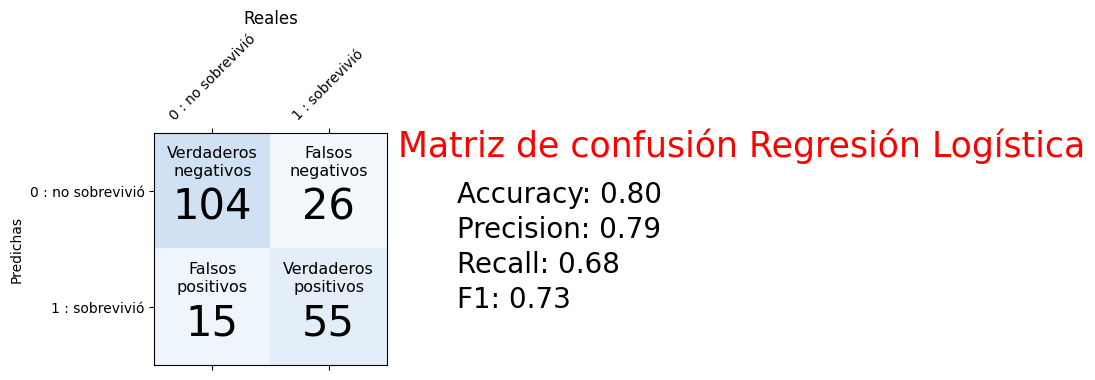

In [103]:
# 4- Evaluamos el desempeño del modelo de regresión logística con la matríz de confusión sobre el conjunto de prueba
visualiza_metricas(y_test, clf.predict(X_test), "Matriz de confusión Regresión Logística")


**Comentario de métrica y matriz de confusión de la regresión logística:**


La matriz de confusión nos da un panorama amplio del desempeño del modelo aplicado y de esta manera no depender mucho del accuracy a la hora de evaluar, evitando de esta manera algunas falsas impresiones. Observamos que alcanzamos al menos el 80% de accuracy solicitado.Las otras métricas de clasificación como lo es la precisión, el recall y el F1 score son menores. Esto nos indica que el modelo de regresión logística acierta muchas de las predicciones y además la precisión nos dice que el nivel de confiabilidad acompaña el rendimiento global del modelo, que vale aclarar que no es el más óptimo al captar todo los positivos reales, tal como lo indica el recall de 68%. 


### 5) Determine un modelo de clasificación del tipo árbol de decisión utilizando los datos de entrenamiento. 
Este modelo debe estimar la **Supervivencia** del pasajero a partir de las variables de entrada. 

In [106]:
# 5- Modelo de clasificación de árbol de decisión

#Mejores parámetros: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}


arbol= DecisionTreeClassifier(max_depth=7,
    min_samples_split=2,
    min_samples_leaf=1,
    criterion="entropy",
    random_state=42)





# Usamos datos de entrenamiento

arbol.fit(X_entrenamiento, y_entrenamiento)

# Observamos la entropia de cada nodo 
print(arbol.tree_.impurity)

[0.97340868 0.81737941 0.32474775 0.55477816 0.46899559 0.37123233
 0.         0.48546076 0.72192809 0.         1.         0.
 0.         0.         0.21639693 1.         0.         0.
 0.16082302 0.         0.23181305 0.91829583 0.         0.
 0.14144054 0.         0.41381685 0.98958752 0.99825457 0.96241274
 0.67229482 0.         0.54356444 0.         0.35335934 0.99901027
 0.         0.97602065 1.         0.         0.87398105 0.43949699
 0.         0.         0.91829583 0.         0.         0.37123233
 1.         0.         0.         0.         0.71688398 0.99403021
 0.         0.         0.66161791 0.93270761 0.         0.96036227
 0.72192809 0.50325833 0.         0.91829583 0.         0.8812909
 0.         0.91087838 0.         0.87566339 0.53283506 0.59560859
 0.         0.58367533 0.57135497 0.59379111 0.         0.
 0.15649106 0.         0.91829583 0.         0.        ]


In [ ]:
#Ajuste de hiperparametros de un arbol de decisión

from sklearn.model_selection import GridSearchCV


# Definimos el espacio de búsqueda más amplio
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, None],
    'min_samples_split': [2, 3, 4, 5, 10],
    'min_samples_leaf': [1, 2, 3, 4, 5, 10],
    'criterion': ['gini', 'entropy', 'log_loss']
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=10, scoring='accuracy')
grid.fit(X_entrenamiento, y_entrenamiento)

# Nuestro mejor parametros posibles son

print("Mejores parámetros:", grid.best_params_)
print("Mejor accuracy promedio:", grid.best_score_)


# Evaluamos en el conjunto de prueba fijo
best_model = grid.best_estimator_
print("Accuracy en test fijo:", best_model.score(X_test, y_test))

Mejores parámetros: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor accuracy promedio: 0.8163273001508295
Accuracy en test fijo: 0.8


### 6) Evalúe el desempeño del modelo de árbol de decisión obtenido en el apartado anterior, a través de la precisión (accuracy) y la matriz de confusión sobre el conjunto de prueba. 
El árbol de decisión debe tener una precisión (accuracy) de al menos 80% sobre los datos de  prueba. Grafique el árbol de decisión obtenido. Comente brevemente sobre los resultados. 

In [107]:
# 5- Graficamos

export_graphviz(arbol, out_file='arbol1.dot', class_names=["No sobrevivio", "Sobrevivio"], feature_names=X.columns, impurity=False, filled=True)

In [35]:
#Agregamos la libreria en la variable de entorno

import os
os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

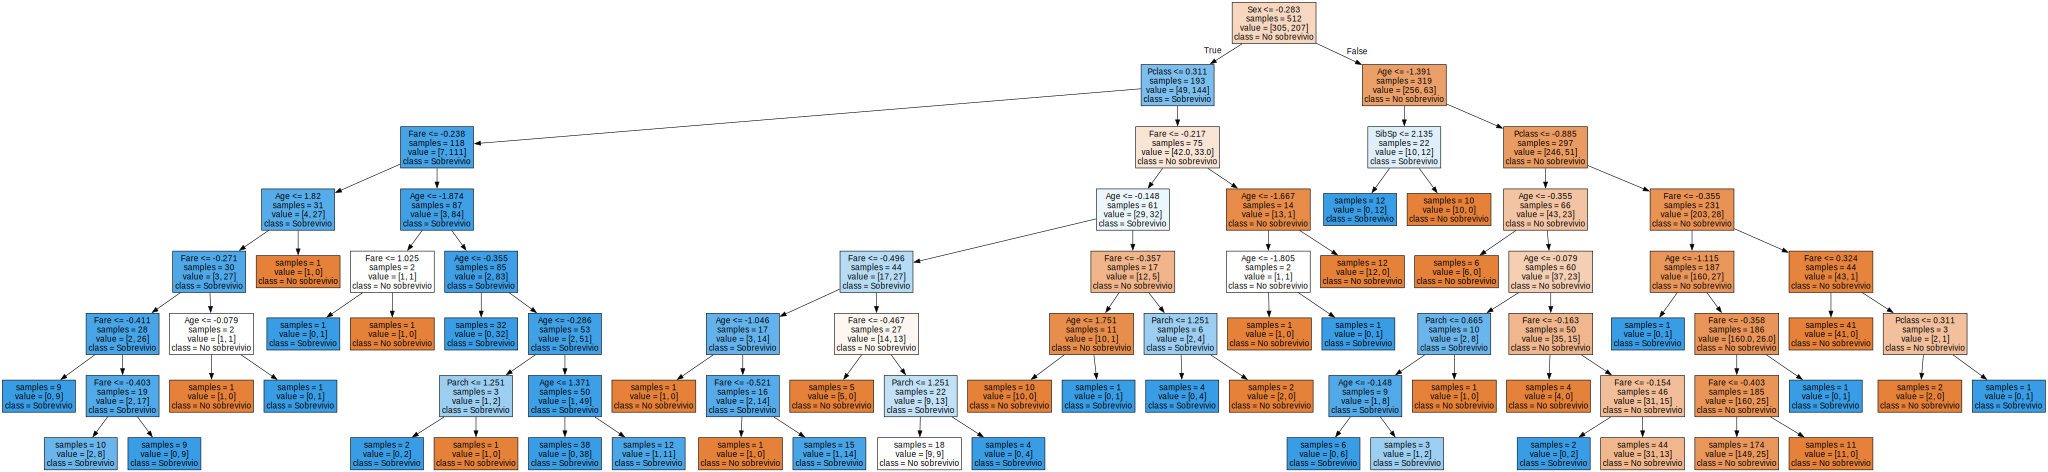

In [108]:
# Recorremos y graficamos

with open('arbol1.dot') as f:
    dot_graph=f.read()
graphviz.Source(dot_graph)

**Comentario sobre el árbol de decisión:**

A través  del ajuste automático de parámetros, con el conocimiento y las herramientas que tengo se logró llegar a un techo de accuracy, alcanzando al menos un 80 %. Como se ve en la imagen, el árbol es bastante extenso, más precisamente de profundidad 7. Entrenamos el modelo utilizando como criterio la entropía para la medida de impureza. Revise la posibilidad de tener un árbol menos profundo, pero esto afectaba directamente al acurracy de este reduciendola y no alcanzado el nivel solicitado.


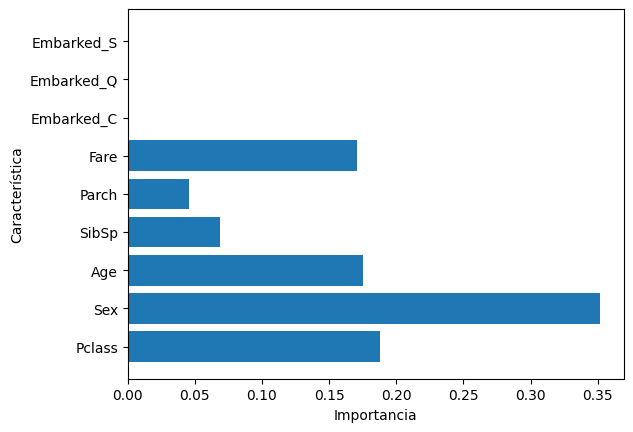

In [114]:
# 6- Desempeño del árbol de decisión, observamos la importancia que tiene cada feature en nuestro arbol

caracteristica=X.shape[1]

plt.barh(range(caracteristica),arbol.feature_importances_)
plt.yticks(np.arange(caracteristica),X.columns)
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()

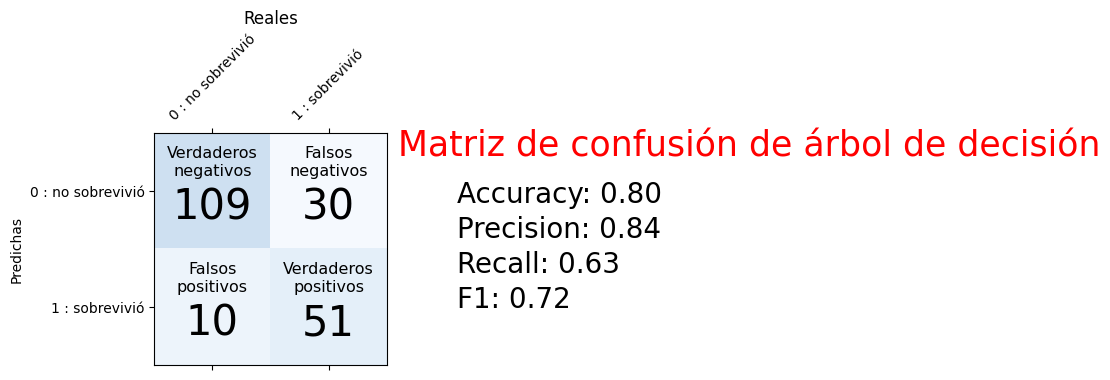

In [112]:
visualiza_metricas(y_test, arbol.predict(X_test), "Matriz de confusión de árbol de decisión")


**Comentario de métricas y matriz de confusión de árbol de decisión:**

Como se puede ver los valores de esta matriz de confusión difieren un poco respecto al de la regresión logística. Este modelo tiene una grado de precisión del  mayor (84%) y un recall menor (63%), esto nos dice que va a poder confirmar positivos pero no va a poder alcanzar todos, tal como se observa en la matriz.


In [113]:
# Observamos el acurracy de nuestros datos fijos de entrenamiento y prueba

print("Datos de entrenamiento",accuracy_score(y_entrenamiento, arbol.predict(X_entrenamiento)))
print("Datos de prueba",accuracy_score(y_test, arbol.predict(X_test)))




Datos de entrenamiento 0.8984375
Datos de prueba 0.8
